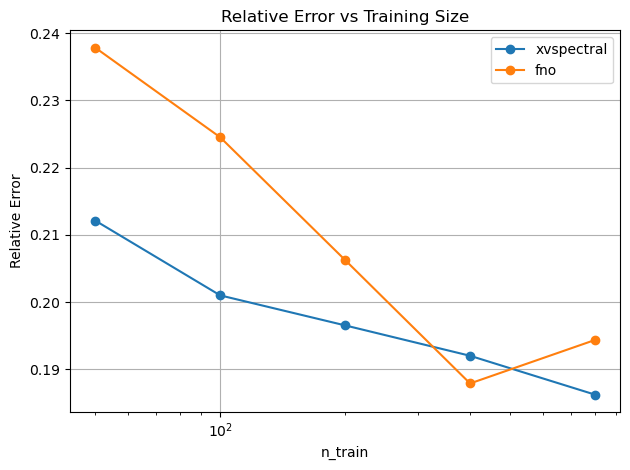

In [5]:
import matplotlib.pyplot as plt

# Read file
filename = "../data/test_errors.txt"

methods = {"xvspectral": [], "fno": []}

with open(filename, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        parts = line.split(",")
        method = parts[0].split("=")[1]
        n_train = int(parts[1].split("=")[1])
        rel_error = float(parts[2].split("=")[1])

        methods[method].append((n_train, rel_error))

# Sort by n_train
for method in methods:
    methods[method] = sorted(methods[method], key=lambda x: x[0])

# Plot
plt.figure()
for method, values in methods.items():
    n_vals = [v[0] for v in values]
    err_vals = [v[1] for v in values]
    plt.plot(n_vals, err_vals, marker='o', label=method)
plt.xscale("log")
plt.xlabel("n_train")
plt.ylabel("Relative Error")
plt.title("Relative Error vs Training Size")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

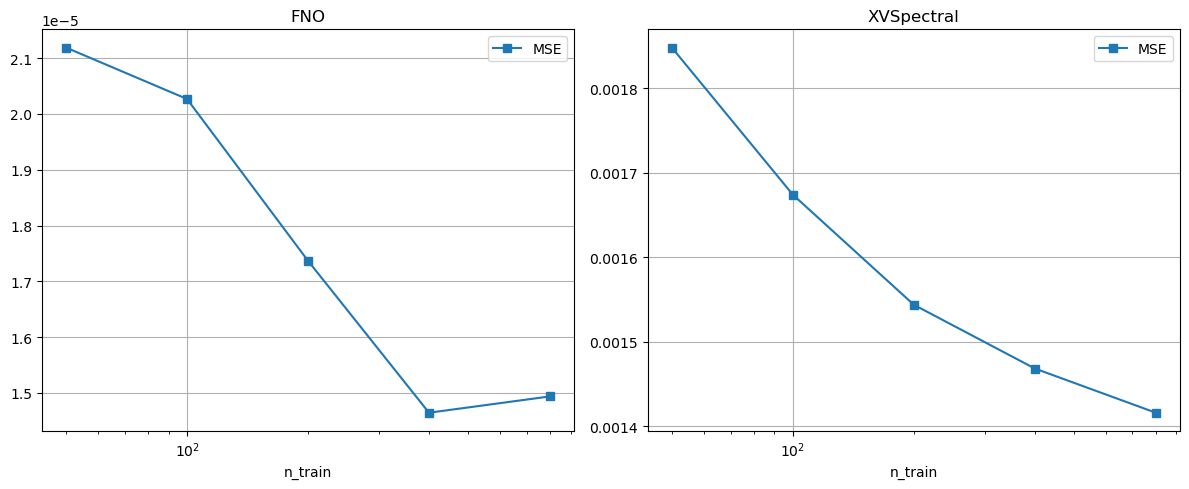

In [11]:
import matplotlib.pyplot as plt

filename = "../data/test_errors.txt"

# Store data
methods = {"xvspectral": [], "fno": []}

# Read file
with open(filename, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue

        parts = line.split(",")
        method = parts[0].split("=")[1]
        n_train = int(parts[1].split("=")[1])
        rel_error = float(parts[2].split("=")[1])
        mse = float(parts[3].split("=")[1])

        methods[method].append((n_train, rel_error, mse))

# Sort by n_train
for method in methods:
    methods[method] = sorted(methods[method], key=lambda x: x[0])

# Create subplots (side by side)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- FNO plot ----
fno_data = methods["fno"]
n_vals = [v[0] for v in fno_data]
rel_vals = [v[1] for v in fno_data]
mse_vals = [v[2] for v in fno_data]
axes[0].set_xscale('log')
axes[0].plot(n_vals, mse_vals, marker='s', label="MSE")
axes[0].set_title("FNO")
axes[0].set_xlabel("n_train")
axes[0].grid(True)
axes[0].legend()

# ---- XVSpectral plot ----
xv_data = methods["xvspectral"]
n_vals = [v[0] for v in xv_data]
rel_vals = [v[1] for v in xv_data]
mse_vals = [v[2] for v in xv_data]
axes[1].set_xscale('log')
axes[1].plot(n_vals, mse_vals, marker='s', label="MSE")
axes[1].set_title("XVSpectral")
axes[1].set_xlabel("n_train")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()